<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales - 1C 2026
# Trabajo Práctico Nº 5: Estimación espectral - Ancho de banda de señales reales
#### Mariano Gonzalez



Se requiere analizar 3 tipos de señales:
- Electrocardiograma (ECG).
- Pletismografía (PPG). 
- Audio: Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

### 1) Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

In [18]:
#variables globales

import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write

eps = 1e-12

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz
signal_ecg= np.load('ecg_sin_ruido.npy')

####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz
signal_ppg = np.load('ppg_sin_ruido.npy')

####################
# Lectura de audio #
####################
 
fs_cuca, wav_cuca = sio.wavfile.read(r'C:/Users/Mariano/Desktop/APS/TS0/TS5/la_cucaracha.wav')
fs_, wav_data = sio.wavfile.read(r'C:/Users/Mariano/Desktop/APS/TS0/TS5/prueba psd.wav')
fs_audio, wav_data = sio.wavfile.read(r'C:/Users/Mariano/Desktop/APS/TS0/TS5/silbido.wav')



### En los siguientes graficos se vera un zoom donde se encuentra el ancho de banda teorico segun cada señal

### Periodograma ventaneado ECG

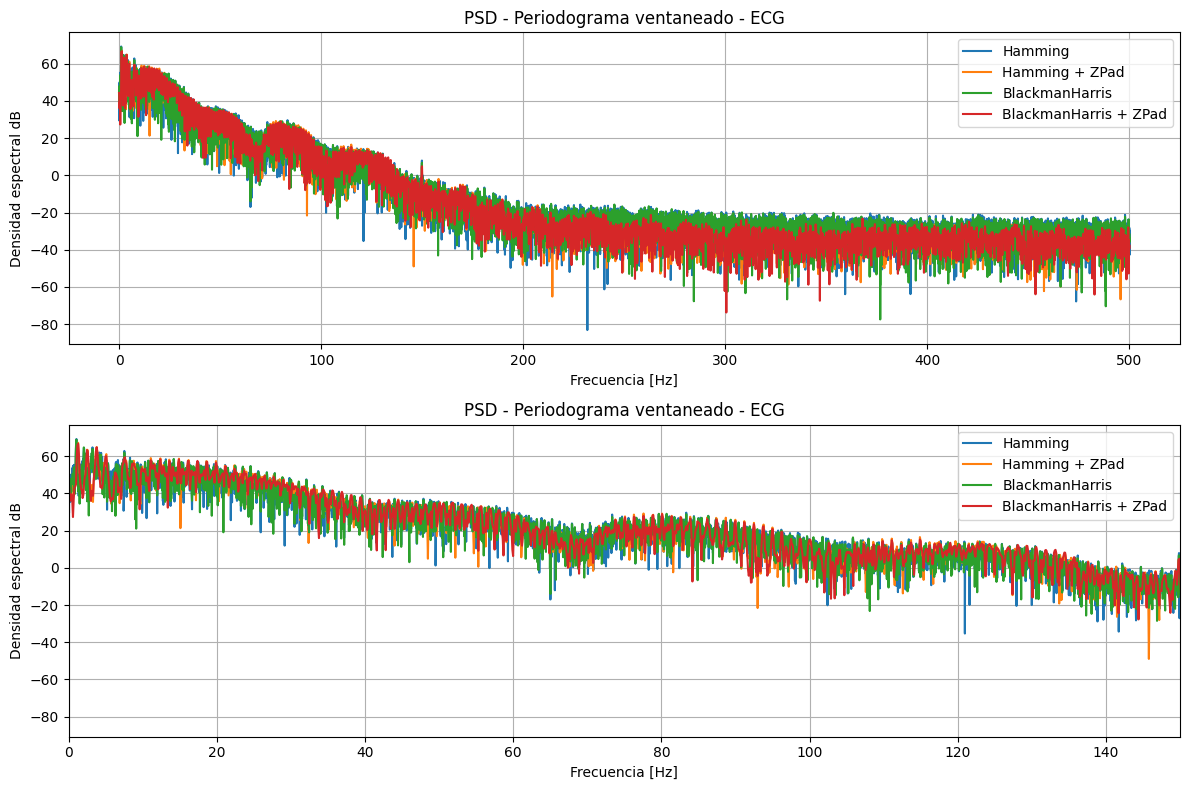

varianza Hamming:    1.4178774e+10
varianza Hamming Zero Padding:    1.73363e+10
varianza BlackHarrys:    1.3746374e+10
varianza BlackHarrys Zero Padding:    1.4716552e+10


In [21]:
# Periodograma ventaneado ECG
f_per_ham, Pxx_per_ham = sig.periodogram(signal_ecg, fs_ecg, window='hamming')
f_per_hamz, Pxx_per_hamz = sig.periodogram(signal_ecg, fs_ecg, window='hamming', nfft=10*fs_ecg )
f_per_blk, Pxx_per_blk = sig.periodogram(signal_ecg, fs_ecg, window='blackmanharris', scaling='density')
f_per_blkz, Pxx_per_blkz = sig.periodogram(signal_ecg, fs_ecg, window='blackmanharris',nfft=10*fs_ecg )
                                         
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# plot 1: espectro completo
ax1.plot(f_per_ham, 10*np.log10(Pxx_per_ham+eps), label='Hamming')
ax1.plot(f_per_hamz, 10*np.log10(Pxx_per_hamz+eps), label='Hamming + ZPad')
ax1.plot(f_per_blk, 10*np.log10(Pxx_per_blk+eps), label='BlackmanHarris')
ax1.plot(f_per_blkz, 10*np.log10(Pxx_per_blkz+eps), label='BlackmanHarris + ZPad')
ax1.set_title("PSD - Periodograma ventaneado - ECG")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral dB")
ax1.legend()
ax1.grid(True)

#plot 2: zoom hasta 150Hz
ax2.plot(f_per_ham, 10*np.log10(Pxx_per_ham+eps), label='Hamming')
ax2.plot(f_per_hamz, 10*np.log10(Pxx_per_hamz+eps), label='Hamming + ZPad')
ax2.plot(f_per_blk, 10*np.log10(Pxx_per_blk+eps), label='BlackmanHarris')
ax2.plot(f_per_blkz, 10*np.log10(Pxx_per_blkz+eps), label='BlackmanHarris + ZPad')
ax2.set_xlim(0,150)
ax2.set_title("PSD - Periodograma ventaneado - ECG")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral dB")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print('varianza Hamming:   ',np.var(Pxx_per_ham))
print('varianza Hamming Zero Padding:   ',np.var(Pxx_per_hamz))
print('varianza BlackHarrys:   ',np.var(Pxx_per_blk))
print('varianza BlackHarrys Zero Padding:   ',np.var(Pxx_per_blkz))

### Periodograma ventaneado PPG

varianza Hamming:    1445133030.6428576
varianza Hamming Zero Padding:    68747791.67537296
varianza BlackHarrys:    1747569314.4426525
varianza BlackHarrys Zero Padding:    73080542.71263304


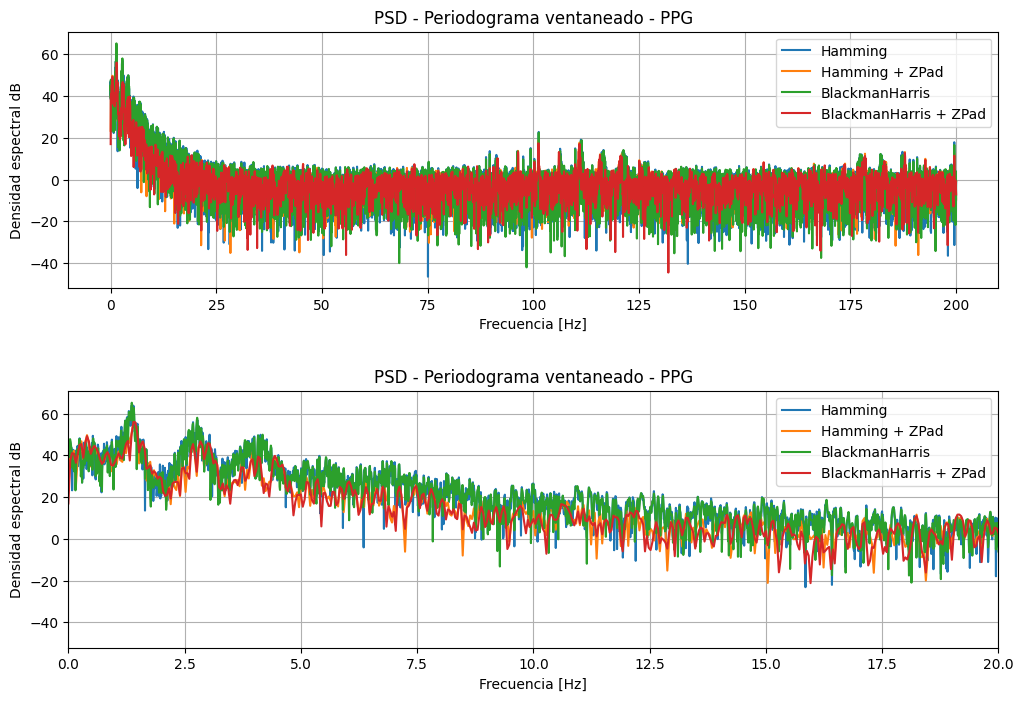

In [25]:
# Periodograma ventaneado PPG
fppg_per_ham, ppg_per_ham = sig.periodogram(signal_ppg, fs_ppg, window='hamming')
fppg_per_hamz, ppg_per_hamz = sig.periodogram(signal_ppg, fs_ppg, window='hamming', nfft=10*fs_ecg )
fppg_per_blk, ppg_per_blk = sig.periodogram(signal_ppg, fs_ppg, window='blackmanharris', scaling='density')
fppg_per_blkz, ppg_per_blkz = sig.periodogram(signal_ppg, fs_ppg, window='blackmanharris',nfft=10*fs_ecg )


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

#plot 1 espectro completo
ax1.plot(fppg_per_ham, 10*np.log10(ppg_per_ham+eps), label='Hamming')
ax1.plot(fppg_per_hamz, 10*np.log10(ppg_per_hamz+eps), label='Hamming + ZPad')
ax1.plot(fppg_per_blk, 10*np.log10(ppg_per_blk+eps), label='BlackmanHarris')
ax1.plot(fppg_per_blkz, 10*np.log10(ppg_per_blkz+eps), label='BlackmanHarris + ZPad')
ax1.set_title("PSD - Periodograma ventaneado - PPG")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral dB")
ax1.legend()
ax1.grid(True)

#plot 2: zoom hasta 20Hz
ax2.plot(fppg_per_ham, 10*np.log10(ppg_per_ham+eps), label='Hamming')
ax2.plot(fppg_per_hamz, 10*np.log10(ppg_per_hamz+eps), label='Hamming + ZPad')
ax2.plot(fppg_per_blk, 10*np.log10(ppg_per_blk+eps), label='BlackmanHarris')
ax2.plot(fppg_per_blkz, 10*np.log10(ppg_per_blkz+eps), label='BlackmanHarris + ZPad')
ax2.set_xlim(0,20)
ax2.set_title("PSD - Periodograma ventaneado - PPG")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral dB")
ax2.legend()
ax2.grid(True)

print('varianza Hamming:   ',np.var(ppg_per_ham))
print('varianza Hamming Zero Padding:   ',np.var(ppg_per_hamz))
print('varianza BlackHarrys:   ',np.var(ppg_per_blk))
print('varianza BlackHarrys Zero Padding:   ',np.var(ppg_per_blkz))


### Periodograma ventaneado Audio

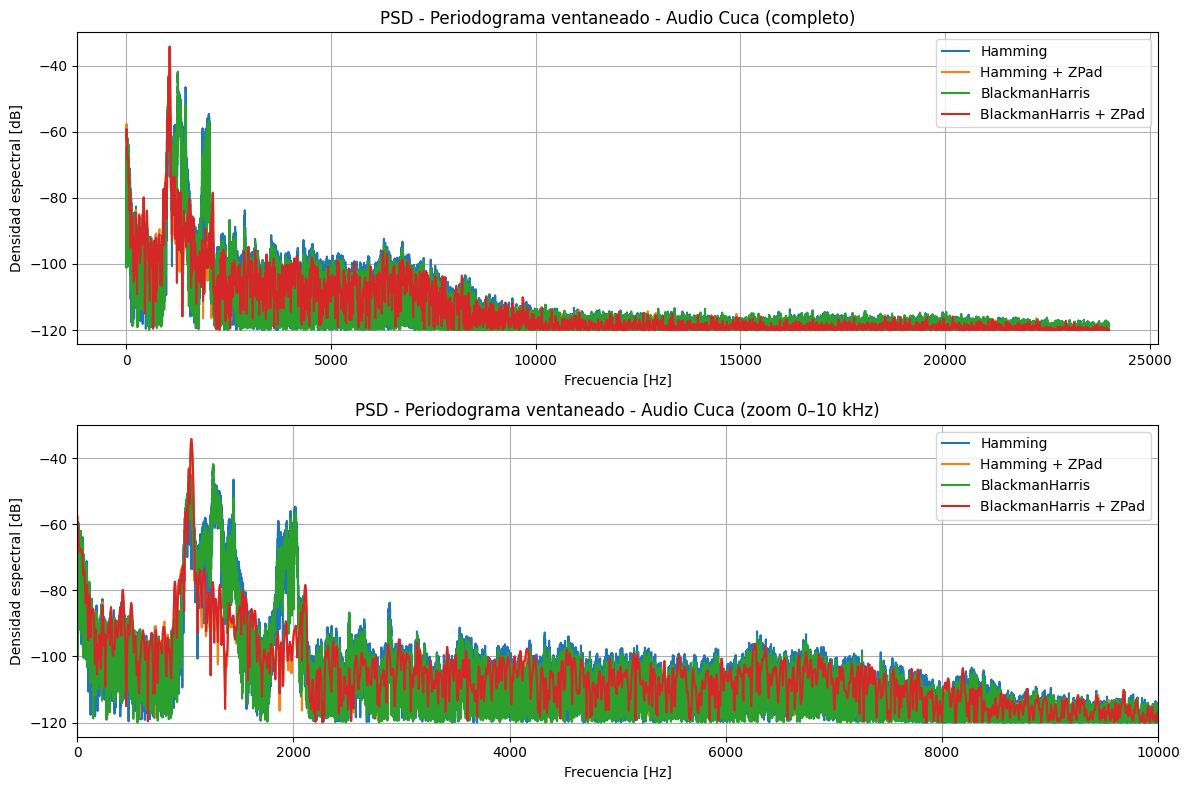

varianza Hamming:                   1.2051837e-12
varianza Hamming Zero Padding:      4.6939046e-11
varianza BlackmanHarris:            1.5000965e-12
varianza BlackmanHarris ZeroPad:    7.497661e-11


In [11]:
# Periodograma ventaneado audio
fcuca_per_ham, cuca_per_ham = sig.periodogram(wav_cuca, fs_cuca, window='hamming')
fcuca_per_hamz, cuca_per_hamz = sig.periodogram(wav_cuca, fs_cuca, window='hamming', nfft=10*fs_ecg)
fcuca_per_blk, cuca_per_blk = sig.periodogram(wav_cuca, fs_cuca, window='blackmanharris', scaling='density')
fcuca_per_blkz, cuca_per_blkz = sig.periodogram(wav_cuca, fs_cuca, window='blackmanharris', nfft=10*fs_ecg)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

#Plot 1 Espectro completo
ax1.plot(fcuca_per_ham,  10*np.log10(cuca_per_ham+eps),  label='Hamming')
ax1.plot(fcuca_per_hamz, 10*np.log10(cuca_per_hamz+eps), label='Hamming + ZPad')
ax1.plot(fcuca_per_blk,  10*np.log10(cuca_per_blk+eps),  label='BlackmanHarris')
ax1.plot(fcuca_per_blkz, 10*np.log10(cuca_per_blkz+eps), label='BlackmanHarris + ZPad')
ax1.set_title("PSD - Periodograma ventaneado - Audio Cuca (completo)")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral [dB]")
ax1.legend()
ax1.grid(True)

#Plot 2 con Zoom hasta 5000 Hz
ax2.plot(fcuca_per_ham,  10*np.log10(cuca_per_ham+eps),  label='Hamming')
ax2.plot(fcuca_per_hamz, 10*np.log10(cuca_per_hamz+eps), label='Hamming + ZPad')
ax2.plot(fcuca_per_blk,  10*np.log10(cuca_per_blk+eps),  label='BlackmanHarris')
ax2.plot(fcuca_per_blkz, 10*np.log10(cuca_per_blkz+eps), label='BlackmanHarris + ZPad')
ax2.set_xlim(0, 5000)
ax2.set_title("PSD - Periodograma ventaneado - Audio Cuca (zoom 0–10 kHz)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral [dB]")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print('varianza Hamming:                  ', np.var(cuca_per_ham))
print('varianza Hamming Zero Padding:     ', np.var(cuca_per_hamz))
print('varianza BlackmanHarris:           ', np.var(cuca_per_blk))
print('varianza BlackmanHarris ZeroPad:   ', np.var(cuca_per_blkz))

### Conclusiones metodo Periodograma

#### Es un estimador con mucha varianza, por lo menos para el ECG y PPG, se ve a grandes rasgos donde se encuentra los picos de densidad espectral segun ancho de banda teorico (ECG=150Hz, PPG=10Hz y audio=20KHz). En "la cucaracha" acorte el zoom a 5KHz para observar mejor el fenomeno, ya se se tratas de bajos y medios, no me sirve evaluar mas arriba ya que no hay o naturalemente la cancion no tiene agudos elevados.

### Metodo Welch ECG

varianza Hamming nperseg 1000:    6.8645135e+09
varianza Hamming nperseg 2000:    5.1614356e+09
varianza BlackHarrys nperseg 1000:    7.3300147e+09
varianza BlackHarrys nperseg 2000:    9.139241e+09


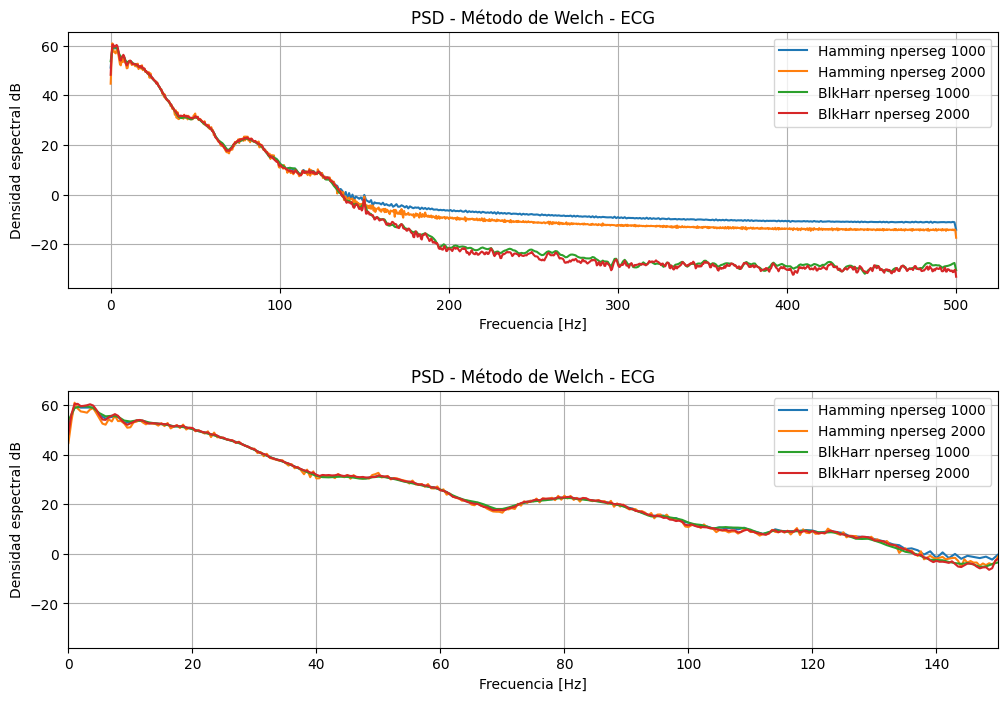

In [27]:
# %% Método de Welch ECG
f_welch, ECG_welch_ham1 = sig.welch(signal_ecg, fs_ecg, 'hamming', axis=-1, nperseg=1000, noverlap=400 )
f_welch2, ECG_welch_ham2 = sig.welch(signal_ecg, fs_ecg, 'hamming', axis=-1, nperseg=2000, noverlap=400 )
f_black2, ECG_welch_blk2 = sig.welch(signal_ecg, fs_ecg, 'blackmanharris', axis=-1, nperseg=1000, noverlap=400)
f_black3, ECG_welch_blk3 = sig.welch(signal_ecg, fs_ecg, 'blackmanharris', axis=-1, nperseg=2000, noverlap=1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

#plot 1 espectro completo
ax1.plot(f_welch, 10*np.log10(ECG_welch_ham1+eps), label='Hamming nperseg 1000')
ax1.plot(f_welch2, 10*np.log10(ECG_welch_ham2+eps), label='Hamming nperseg 2000')
ax1.plot(f_black2, 10*np.log10(ECG_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax1.plot(f_black3, 10*np.log10(ECG_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax1.set_title("PSD - Método de Welch - ECG")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral dB")
ax1.legend()
ax1.grid(True)

#plot 2 zoom hasta 150Hz
ax2.plot(f_welch, 10*np.log10(ECG_welch_ham1+eps), label='Hamming nperseg 1000')
ax2.plot(f_welch2, 10*np.log10(ECG_welch_ham2+eps), label='Hamming nperseg 2000')
ax2.plot(f_black2, 10*np.log10(ECG_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax2.plot(f_black3, 10*np.log10(ECG_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax2.set_xlim(0,150)
ax2.set_title("PSD - Método de Welch - ECG")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral dB")
ax2.legend()
ax2.grid(True)

print('varianza Hamming nperseg 1000:   ',np.var(ECG_welch_ham1))
print('varianza Hamming nperseg 2000:   ',np.var(ECG_welch_ham2))
print('varianza BlackHarrys nperseg 1000:   ',np.var(ECG_welch_blk2))
print('varianza BlackHarrys nperseg 2000:   ',np.var(ECG_welch_blk3))


### Metodo Welch PPG

varianza Hamming nperseg 1000:    201643658.42503804
varianza Hamming nperseg 2000:    323600120.82171416
varianza BlackHarrys nperseg 1000:    161498249.91681683
varianza BlackHarrys nperseg 2000:    245454222.4744799


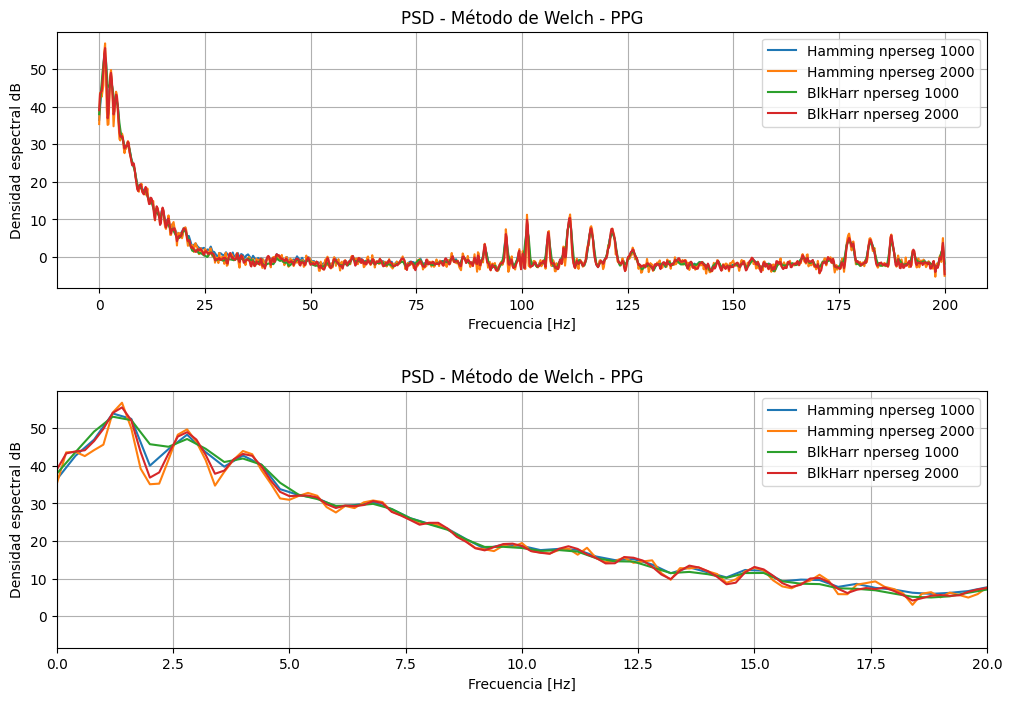

In [30]:

# %% Método de Welch PPG
fppg_welch, PPG_welch_ham1 = sig.welch(signal_ppg, fs_ppg, 'hamming', axis=-1, nperseg=1000, noverlap=400 )
fppg_welch2, PPG_welch_ham2 = sig.welch(signal_ppg, fs_ppg, 'hamming', axis=-1, nperseg=2000, noverlap=400 )
fppg_black2, PPG_welch_blk2 = sig.welch(signal_ppg, fs_ppg, 'blackmanharris', axis=-1, nperseg=1000, noverlap=400)
fppg_black3, PPG_welch_blk3 = sig.welch(signal_ppg, fs_ppg, 'blackmanharris', axis=-1, nperseg=2000, noverlap=1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

ax1.plot(fppg_welch, 10*np.log10(PPG_welch_ham1+eps), label='Hamming nperseg 1000')
ax1.plot(fppg_welch2, 10*np.log10(PPG_welch_ham2+eps), label='Hamming nperseg 2000')
ax1.plot(fppg_black2, 10*np.log10(PPG_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax1.plot(fppg_black3, 10*np.log10(PPG_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax1.set_title("PSD - Método de Welch - PPG")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral dB")
ax1.legend()
ax1.grid(True)
#plot 2 zoom hasta 20Hz
ax2.plot(fppg_welch, 10*np.log10(PPG_welch_ham1+eps), label='Hamming nperseg 1000')
ax2.plot(fppg_welch2, 10*np.log10(PPG_welch_ham2+eps), label='Hamming nperseg 2000')
ax2.plot(fppg_black2, 10*np.log10(PPG_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax2.plot(fppg_black3, 10*np.log10(PPG_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax2.set_xlim(0,20)
ax2.set_title("PSD - Método de Welch - PPG")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral dB")
ax2.legend()
ax2.grid(True)

print('varianza Hamming nperseg 1000:   ',np.var(PPG_welch_ham1))
print('varianza Hamming nperseg 2000:   ',np.var(PPG_welch_ham2))
print('varianza BlackHarrys nperseg 1000:   ',np.var(PPG_welch_blk2))
print('varianza BlackHarrys nperseg 2000:   ',np.var(PPG_welch_blk3))




### Metodo Welch Audio Cuca

varianza Hamming nperseg 1000:    4.2452435e-13
varianza Hamming nperseg 2000:    6.6999563e-13
varianza BlackHarrys nperseg 1000:    3.1575347e-13
varianza BlackHarrys nperseg 2000:    5.118302e-13


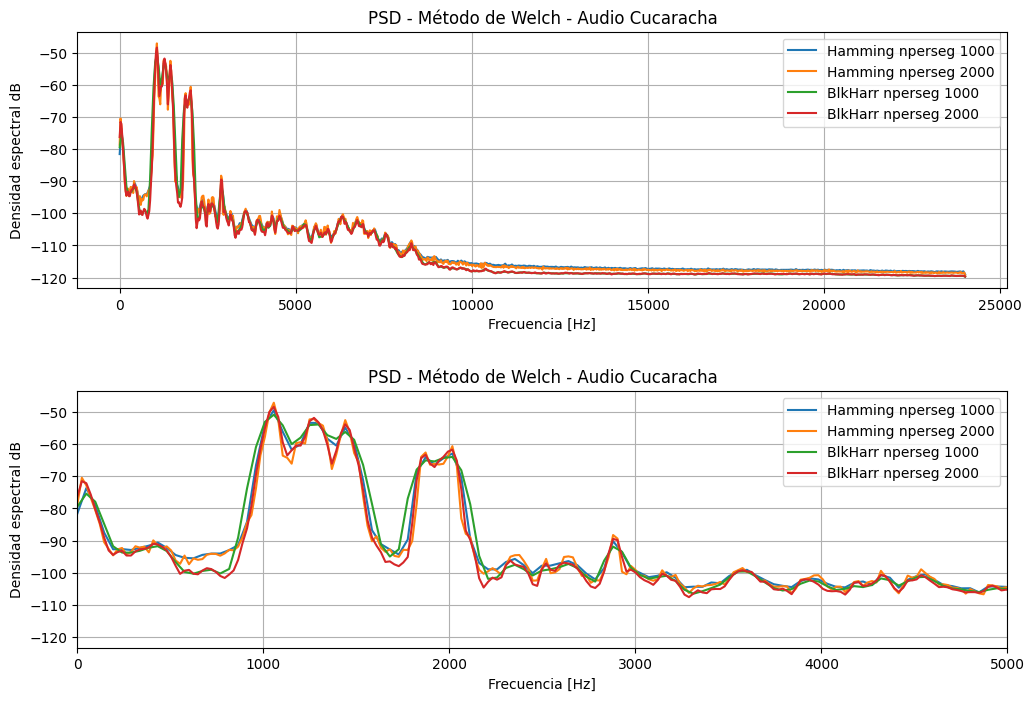

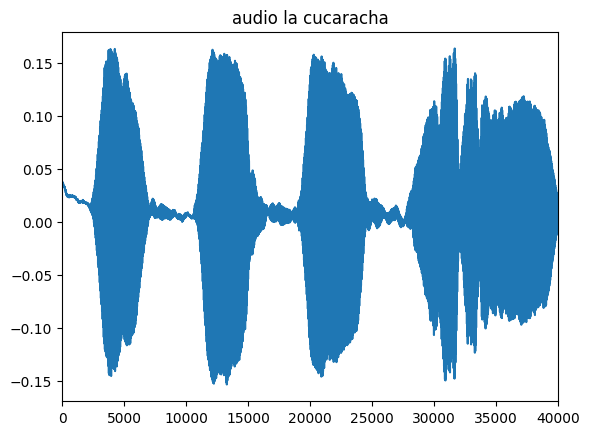

In [41]:
# %% Método de Welch ECG
fcuca_welch, cuca_welch_ham1 = sig.welch(wav_cuca, fs_cuca, 'hamming', axis=-1, nperseg=1000, noverlap=400 )
fcuca_welch2, cuca_welch_ham2 = sig.welch(wav_cuca, fs_cuca, 'hamming', axis=-1, nperseg=2000, noverlap=400 )
fcuca_black2, cuca_welch_blk2 = sig.welch(wav_cuca, fs_cuca, 'blackmanharris', axis=-1, nperseg=1000, noverlap=400)
fcuca_black3, cuca_welch_blk3 = sig.welch(wav_cuca, fs_cuca, 'blackmanharris', axis=-1, nperseg=2000, noverlap=1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

ax1.plot(fcuca_welch, 10*np.log10(cuca_welch_ham1+eps), label='Hamming nperseg 1000')
ax1.plot(fcuca_welch2, 10*np.log10(cuca_welch_ham2+eps), label='Hamming nperseg 2000')
ax1.plot(fcuca_black2, 10*np.log10(cuca_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax1.plot(fcuca_black3, 10*np.log10(cuca_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax1.set_title("PSD - Método de Welch - Audio Cucaracha")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad espectral dB")
ax1.legend()
ax1.grid(True)

ax2.plot(fcuca_welch, 10*np.log10(cuca_welch_ham1+eps), label='Hamming nperseg 1000')
ax2.plot(fcuca_welch2, 10*np.log10(cuca_welch_ham2+eps), label='Hamming nperseg 2000')
ax2.plot(fcuca_black2, 10*np.log10(cuca_welch_blk2+eps), label='BlkHarr nperseg 1000')
ax2.plot(fcuca_black3, 10*np.log10(cuca_welch_blk3+eps), label='BlkHarr nperseg 2000')
ax2.set_xlim(0,5000)
ax2.set_title("PSD - Método de Welch - Audio Cucaracha")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad espectral dB")
ax2.legend()
ax2.grid(True)

plt.figure()
plt.title("audio la cucaracha")
plt.plot(wav_cuca)
plt.xlim(0,40000)

print('varianza Hamming nperseg 1000:   ',np.var(cuca_welch_ham1))
print('varianza Hamming nperseg 2000:   ',np.var(cuca_welch_ham2))
print('varianza BlackHarrys nperseg 1000:   ',np.var(cuca_welch_blk2))
print('varianza BlackHarrys nperseg 2000:   ',np.var(cuca_welch_blk3))

### Conclusiones metodo Welch

#### Con este metodo se aprecia una disminucion de la varianza.Para el caso del audio "la cucaracha" vemos en el grafico de zoom hasta 5kHz los claros 3 picos de densidad espectral naturales de la cancion y al final el "chaaa" de menor amplitud, vease tambien un fragmento de la primera parte de la cancion debajo del grafico de zoom para hacer una correlacion entre el audio y la PSD. tambien podemos ver que si bien la varianza en blackmanharris y hamming con menos segmentos y solapados 1000 muestras tiene la mejor varianza, yo personalemente me quedo con blackmanharris 2000 nperseg (con varianza "peor") ya que veo que en los silencios donde se cambia de silabas atenua mas y eso me garantiza que cualquier ruido ajeno a la cancion lo va a "matar". Luego la envolvente va bastante pareja en relacion a las demas estimaciones. 

### 2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

In [13]:
#funcion para estimar ancho de banda

def estimar_ancho_banda(f, psd, umbral):
    """
    Retorna la frecuencia donde se acumula el `umbral` de la energía total.
    """
    energia_acumulada = np.cumsum(psd)
    energia_total = energia_acumulada[-1]
    idx = np.searchsorted(energia_acumulada, umbral * energia_total)
    return f[idx]


In [8]:
# BW periodograma ECG
bw95_per_ham = estimar_ancho_banda(f_per_ham, Pxx_per_ham, 0.95)
bw95_per_hamz = estimar_ancho_banda(f_per_hamz, Pxx_per_hamz, 0.95)
bw95_per_black = estimar_ancho_banda(f_per_blk, Pxx_per_blk, 0.95)
bw95_per_blackz = estimar_ancho_banda(f_per_blkz, Pxx_per_blkz, 0.95)

print(f"ECG Periodograma Haming - BW 95%: {bw95_per_ham:.1f} Hz")
print(f"ECG Periodograma Haming + ZP - BW 95%: {bw95_per_hamz:.1f} Hz")
print(f"ECG Periodograma Blakmanharris - BW 95%: {bw95_per_black:.1f} Hz")
print(f"ECG Periodograma Blakmanharris + ZP - BW 95%: {bw95_per_blackz:.1f} Hz")


ECG Periodograma Haming - BW 95%: 23.6 Hz
ECG Periodograma Haming + ZP - BW 95%: 24.8 Hz
ECG Periodograma Blakmanharris - BW 95%: 24.0 Hz
ECG Periodograma Blakmanharris + ZP - BW 95%: 25.0 Hz


In [14]:
# BW Welch ECG
bw95_ham1 = estimar_ancho_banda(f_welch, ECG_welch_ham1, 0.95)
bw95_ham2 = estimar_ancho_banda(f_welch2, ECG_welch_ham2, 0.95)
bw95_black2 = estimar_ancho_banda(f_black2, ECG_welch_blk2, 0.95)
bw95_black3 = estimar_ancho_banda(f_black3, ECG_welch_blk3, 0.95)

print(f"ECG Welch Haming nperseg=1000 - BW 95%: {bw95_ham1:.1f} Hz")
print(f"ECG Welch Haming nperseg=2000 - BW 95%: {bw95_ham2:.1f} Hz")
print(f"ECG Welch BlackmanHarris nperseg=1000 - BW 95%: {bw95_black2:.1f} Hz")
print(f"ECG Welch BlackmanHarris nperseg=2000 - BW 95%: { bw95_black3:.1f} Hz")



ECG Welch Haming 1000 - BW 95%: 23.0 Hz
ECG Welch Haming 2000 - BW 95%: 23.5 Hz
ECG Welch BlackmanHarris 1000 - BW 95%: 22.0 Hz
ECG Welch BlackmanHarris 2000 - BW 95%: 22.5 Hz


In [25]:
# BW PPG periodograma
bwppg_per_ham = estimar_ancho_banda(fppg_per_ham, ppg_per_ham, 0.95)
bwppg_per_hamz = estimar_ancho_banda(fppg_per_hamz, ppg_per_hamz, 0.95)
bwppg_per_black = estimar_ancho_banda(fppg_per_blk, ppg_per_blk, 0.95)
bwppg_per_blackz = estimar_ancho_banda(fppg_per_blkz, ppg_per_blkz, 0.95)

print(f"PPG Periodograma Haming - BW 95%: {bwppg_per_ham:.1f} Hz")
print(f"PPG Periodograma Haming + ZP - BW 95%: {bwppg_per_hamz:.1f} Hz")
print(f"PPG Periodograma Blakmanharris - BW 95%: {bwppg_per_black:.1f} Hz")
print(f"PPG Periodograma Blakmanharris + ZP - BW 95%: {bwppg_per_blackz:.1f} Hz")

PPG Periodograma Haming - BW 95%: 4.0 Hz
PPG Periodograma Haming + ZP - BW 95%: 3.8 Hz
PPG Periodograma Blakmanharris - BW 95%: 4.0 Hz
PPG Periodograma Blakmanharris + ZP - BW 95%: 3.2 Hz


In [17]:
# BW Welch PPG
bwppg_welch_ham1 = estimar_ancho_banda(fppg_welch, PPG_welch_ham1, 0.95)
bwppg_welch_ham2 = estimar_ancho_banda(fppg_welch2, PPG_welch_ham2, 0.95)
bwppg_welch_black2 = estimar_ancho_banda(fppg_black2, PPG_welch_blk2, 0.95)
bwppg_welch_black3 = estimar_ancho_banda(fppg_black3, PPG_welch_blk3, 0.95)

print(f"PPG Welch Haming nperseg=1000 - BW 95%: {bwppg_welch_ham1:.1f} Hz")
print(f"PPG Welch Haming nperseg=2000 - BW 95%: {bwppg_welch_ham2:.1f} Hz")
print(f"PPG Welch BlackmanHarris nperseg=1000 - BW 95%: {bwppg_welch_black2:.1f} Hz")
print(f"PPG Welch BlackmanHarris nperseg=2000 - BW 95%: { bwppg_welch_black3:.1f} Hz")

PPG Welch Haming 1000 - BW 95%: 4.0 Hz
PPG Welch Haming 2000 - BW 95%: 4.0 Hz
PPG Welch BlackmanHarris 1000 - BW 95%: 4.0 Hz
PPG Welch BlackmanHarris 2000 - BW 95%: 4.0 Hz


In [40]:
#BW Cuacaracha periodograma
bwcuca_per_ham = estimar_ancho_banda(fcuca_per_ham, cuca_per_ham, 0.95)
bwcuca_per_hamz = estimar_ancho_banda(fcuca_per_hamz, fcuca_per_hamz, 0.95)
bwcuca_per_black = estimar_ancho_banda(fcuca_per_blk, cuca_per_blk, 0.95)
bwcuca_per_blackz = estimar_ancho_banda(fcuca_per_blkz, fcuca_per_blkz, 0.95)

print(f"PPG Periodograma Haming - BW 95%: {bwcuca_per_ham:.1f} Hz")
print(f"PPG Periodograma Haming + ZP - BW 95%: {bwcuca_per_hamz:.1f} Hz")
print(f"PPG Periodograma Blakmanharris - BW 95%: {bwcuca_per_black:.1f} Hz")
print(f"PPG Periodograma Blakmanharris + ZP - BW 95%: {bwcuca_per_blackz:.1f} Hz")

PPG Periodograma Haming - BW 95%: 1862.7 Hz
PPG Periodograma Haming + ZP - BW 95%: 23395.2 Hz
PPG Periodograma Blakmanharris - BW 95%: 1444.0 Hz
PPG Periodograma Blakmanharris + ZP - BW 95%: 23395.2 Hz


In [37]:
# BW Cucaracha welch
bwcuca_welch_ham1 = estimar_ancho_banda(fcuca_welch, cuca_welch_ham1, 0.95)
bwcuca_welch_ham2 = estimar_ancho_banda(fcuca_welch2, cuca_welch_ham2, 0.95)
bwcuca_welch_black2 = estimar_ancho_banda(fcuca_black2, cuca_welch_blk2, 0.95)
bwcuca_welch_black3 = estimar_ancho_banda(fcuca_black3, cuca_welch_blk3, 0.95)

print(f"Cuca Welch Haming nperseg 1000- BW 95%: {bwcuca_welch_ham1:.1f} Hz")
print(f"Cuca Welch Haming nperseg 2000 - BW 95%: {bwcuca_welch_ham2:.1f} Hz")
print(f"Cuca Welch Blakmanharris nperseg 1000 - BW 95%: {bwcuca_welch_black2:.1f} Hz")
print(f"Cuca Welch Blakmanharris nperseg 2000 - BW 95%: {bwcuca_welch_black3:.1f} Hz")

Cuca Welch Haming nperseg 1000- BW 95%: 1488.0 Hz
Cuca Welch Haming nperseg 2000 - BW 95%: 1488.0 Hz
Cuca Welch Blakmanharris nperseg 1000 - BW 95%: 1536.0 Hz
Cuca Welch Blakmanharris nperseg 2000 - BW 95%: 1512.0 Hz


### Conclusiones estimacion ancho de banda

#### En las estimaciones de PPG y ECG no hay demasiada variacion, pero en el audio si: para el caso del periodograma con zero padding veo mayor ancho de banda, eso es porque al poner ceros tengo la energia repartida en mas cantidad de bins que sin Zero padding, entonces da la sensacion que tengo un mayor ancho de banda. No recomendaria estimar bajo este metodo